# Latihan 5.1: Parameter Pre-Pruning
Grid search `max_depth` x `min_samples_leaf` pada Decision Tree (dataset Breast Cancer Wisconsin). Dijalankan di Google Colab, tinggal **Runtime > Run all**.


---------- Persiapan data ----------


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Ukuran data latih:", X_train.shape)
print("Ukuran data uji  :", X_test.shape)



Ukuran data latih: (455, 30)
Ukuran data uji  : (114, 30)


---------- Latihan 1: grid search max_depth x min_samples_leaf ----------


In [2]:
print(f"{'max_depth':>10s} | {'min_samples_leaf':>16s} | {'Akurasi Test':>12s}")
print("-" * 46)

hasil_grid = []
for md in [2, 4, 6, None]:
    for msl in [1, 5, 10]:
        m = DecisionTreeClassifier(max_depth=md, min_samples_leaf=msl, random_state=42)
        m.fit(X_train, y_train)
        ak = accuracy_score(y_test, m.predict(X_test))
        hasil_grid.append((ak, md, msl))
        print(f"{str(md):>10s} | {msl:16d} | {ak:12.4f}")

terbaik = max(hasil_grid, key=lambda t: t[0])
print(f"\nKombinasi terbaik: max_depth={terbaik[1]}, min_samples_leaf={terbaik[2]} "
      f"-> akurasi test {terbaik[0]:.4f}")



 max_depth | min_samples_leaf | Akurasi Test
----------------------------------------------
         2 |                1 |       0.8947
         2 |                5 |       0.8947
         2 |               10 |       0.9035
         4 |                1 |       0.9386
         4 |                5 |       0.9211
         4 |               10 |       0.9474
         6 |                1 |       0.9123
         6 |                5 |       0.9298
         6 |               10 |       0.9474
      None |                1 |       0.9123
      None |                5 |       0.9298
      None |               10 |       0.9474

Kombinasi terbaik: max_depth=4, min_samples_leaf=10 -> akurasi test 0.9474


---------- Grafik: heatmap akurasi test ----------


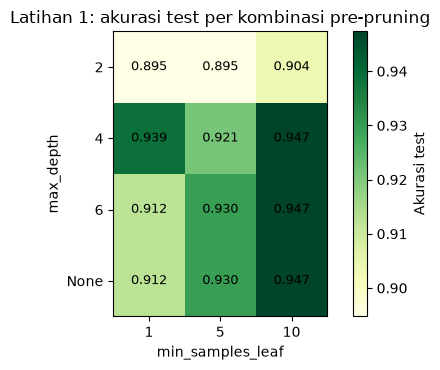

In [3]:
mat = pd.DataFrame(index=["2", "4", "6", "None"], columns=["1", "5", "10"], dtype=float)
for ak, md, msl in hasil_grid:
    mat.loc[str(md), str(msl)] = ak
plt.figure(figsize=(5.5, 3.8))
im = plt.imshow(mat.values, cmap="YlGn")
plt.xticks(range(3), ["1", "5", "10"])
plt.yticks(range(4), ["2", "4", "6", "None"])
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("Latihan 1: akurasi test per kombinasi pre-pruning")
for r in range(4):
    for c_ in range(3):
        plt.text(c_, r, f"{mat.values[r, c_]:.3f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, label="Akurasi test")
plt.tight_layout()
plt.show()

